### Imports

In [1]:
import pandas as pd
import pickle
import csv
import matplotlib.pyplot as plt
import os
import numpy as np

In [13]:
tensor_3d = np.array([
    [  # Première "couche"
        [1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]
    ],
    [  # Deuxième "couche"
        [10, 11, 12],
        [13, 14, 15],
        [16, 17, 18]
    ],
    [  # Troisième "couche"
        [19, 20, 21],
        [22, 23, 24],
        [25, 26, 27]
    ]
])
print(tensor_3d.shape)
max_values = tensor_3d.max(axis=(1, 2))
print(max_values)

tensor_3d / max_values[:, np.newaxis, np.newaxis]

(3, 3, 3)
[ 9 18 27]


array([[[0.11111111, 0.22222222, 0.33333333],
        [0.44444444, 0.55555556, 0.66666667],
        [0.77777778, 0.88888889, 1.        ]],

       [[0.55555556, 0.61111111, 0.66666667],
        [0.72222222, 0.77777778, 0.83333333],
        [0.88888889, 0.94444444, 1.        ]],

       [[0.7037037 , 0.74074074, 0.77777778],
        [0.81481481, 0.85185185, 0.88888889],
        [0.92592593, 0.96296296, 1.        ]]])

Créer classe Barcelona

Attribute = 3D tensor

### Preprocess

NaN -> 0

In [2]:
# Dossier contenant tes fichiers
dossier = r"D:\EPFL\MA2\Projet\Code\Data\datasets\simbarca\all_agg"  # Remplace par le vrai chemin

# Lister tous les fichiers pickle dans le dossier
fichiers_pkl = [f for f in os.listdir(dossier) if f.endswith(".pkl")]

# Traiter chaque fichier
for fichier in fichiers_pkl:
    chemin_fichier = os.path.join(dossier, fichier)
    
    # Charger le fichier pickle
    with open(chemin_fichier, "rb") as f:
        data = pickle.load(f)
    
    # Vérifier que c'est un dictionnaire contenant des DataFrames
    if isinstance(data, dict):
        for key in data.keys():
            if isinstance(data[key], pd.DataFrame):
                data[key].fillna(0, inplace=True)  # Remplacer NaN par 0
                
    # Sauvegarder le fichier modifié
    with open(chemin_fichier, "wb") as f:
        pickle.dump(data, f)

    print(f"✅ NaN remplacés dans {fichier}")

print("🎉 Tous les fichiers ont été traités !")

✅ NaN remplacés dans agg_timeseries_000.pkl
✅ NaN remplacés dans agg_timeseries_001.pkl
✅ NaN remplacés dans agg_timeseries_002.pkl
✅ NaN remplacés dans agg_timeseries_003.pkl
✅ NaN remplacés dans agg_timeseries_004.pkl
✅ NaN remplacés dans agg_timeseries_005.pkl
✅ NaN remplacés dans agg_timeseries_006.pkl
✅ NaN remplacés dans agg_timeseries_007.pkl
✅ NaN remplacés dans agg_timeseries_008.pkl
✅ NaN remplacés dans agg_timeseries_009.pkl
✅ NaN remplacés dans agg_timeseries_010.pkl
✅ NaN remplacés dans agg_timeseries_011.pkl
✅ NaN remplacés dans agg_timeseries_012.pkl
✅ NaN remplacés dans agg_timeseries_013.pkl
✅ NaN remplacés dans agg_timeseries_014.pkl
✅ NaN remplacés dans agg_timeseries_015.pkl
✅ NaN remplacés dans agg_timeseries_016.pkl
✅ NaN remplacés dans agg_timeseries_017.pkl
✅ NaN remplacés dans agg_timeseries_018.pkl
✅ NaN remplacés dans agg_timeseries_019.pkl
✅ NaN remplacés dans agg_timeseries_020.pkl
✅ NaN remplacés dans agg_timeseries_021.pkl
✅ NaN remplacés dans agg_timeser

Check if done correctly.

In [7]:
with open(r"D:\EPFL\MA2\Projet\Code\Data\datasets\simbarca\all_agg\agg_timeseries_000.pkl", "rb") as f:
    data = pickle.load(f)

print(type(data))
print(data.keys())

<class 'collections.defaultdict'>
dict_keys(['drone_vdist', 'drone_vtime', 'ld_speed', 'pred_vdist', 'pred_vtime'])


In [2]:

# Dossier où se trouvent les fichiers
dossier = r"D:\EPFL\MA2\Projet\Code\Data\datasets\simbarca\all_agg"

def charger_fichier(numero):
    """Charge un fichier .pkl en fonction de son numéro"""
    
    # Construire le nom du fichier avec le bon format
    nom_fichier = f"agg_timeseries_{numero}.pkl"
    chemin_fichier = os.path.join(dossier, nom_fichier)
    
    # Vérifier si le fichier existe
    if not os.path.exists(chemin_fichier):
        print(f"❌ Fichier {nom_fichier} non trouvé !")
        return None

    # Charger le fichier pickle
    with open(chemin_fichier, "rb") as f:
        data = pickle.load(f)
    
    print(f"✅ Fichier {nom_fichier} chargé avec succès !")
    return data  # Retourne le contenu du fichier

# Exemple d'utilisation
numero_fichier = "000"  # Choisir un numéro de fichier
data = charger_fichier(numero_fichier)

# Vérifier le contenu si le fichier est bien chargé
if data is not None:
    print(f"Clés disponibles : {list(data.keys())}")


✅ Fichier agg_timeseries_000.pkl chargé avec succès !
Clés disponibles : ['drone_vdist', 'drone_vtime', 'ld_speed', 'pred_vdist', 'pred_vtime']


In [3]:
data['ld_speed'].shape

(54, 1570)

In [4]:
df_vdist = data['drone_vdist'] # Toutes les 5 secondes
df_vtime = data['drone_vtime'] # la même
df_linkSpeed = data['ld_speed'] # toutes les 3 minutes
df_pred_vdist = data['pred_vdist'] # ""
df_pred_vtime = data['pred_vtime'] # ""
type(data['drone_vdist'])

pandas.core.frame.DataFrame

In [7]:
print(sum(df_vdist.isna().sum()))
print(sum(df_vtime.isna().sum()))
print(sum(df_linkSpeed.isna().sum()))
print(sum(df_pred_vdist.isna().sum()))
print(sum(df_pred_vtime.isna().sum()))


0
0
0
0
0


In [7]:
df_pred_vdist.shape

(54, 1570)

In [9]:
df_vtime.head()

section,512,513,514,516,593,594,595,596,597,598,...,64715,64751,64752,68076,69616,69622,70330,72127,73054,73546
time,,,,,,,,,,,,,,,,,,,,,
2005-05-10 07:45:05,0.0,0.0,0.0,1.585445,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2005-05-10 07:45:10,0.0,0.0,0.0,5.000000,0.0,3.398139,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.649569
2005-05-10 07:45:15,0.0,0.0,0.0,3.900724,0.0,3.725736,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.000000
2005-05-10 07:45:20,0.0,0.0,0.0,0.000000,0.0,9.663371,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.254412
2005-05-10 07:45:25,0.0,0.0,0.0,0.000000,0.0,7.581910,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.316415


In [10]:
df_linkSpeed.head()

section,512,513,514,516,593,594,595,596,597,598,...,64715,64751,64752,68076,69616,69622,70330,72127,73054,73546
time,,,,,,,,,,,,,,,,,,,,,
2005-05-10 07:48:00,0.000000,11.404639,11.069793,10.306622,0.000000,10.732761,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,8.633578,0.000000,11.051522
2005-05-10 07:51:00,11.546255,10.745354,11.502900,10.259055,11.557406,11.352791,0.0,11.393155,11.446191,10.130130,...,0.0,0.0,0.0,0.000000,0.0,7.831341,11.103996,10.547758,11.174799,10.955367
2005-05-10 07:54:00,11.360561,9.946858,10.903842,9.730855,10.714279,10.850517,0.0,10.862608,10.846595,9.294876,...,0.0,0.0,0.0,0.000000,0.0,7.810169,9.411075,11.458904,10.176731,10.699288
2005-05-10 07:57:00,10.377132,9.978746,11.079693,10.239193,11.465084,11.422663,0.0,11.485102,11.468658,10.193103,...,0.0,0.0,0.0,0.000000,0.0,6.566019,9.793065,8.694662,10.272738,10.948975
2005-05-10 08:00:00,10.099598,10.778375,10.390805,10.758182,10.697243,11.173762,0.0,10.641167,10.648340,9.481818,...,0.0,0.0,0.0,5.204891,0.0,5.134694,9.332022,8.636250,0.000000,11.485636


In [11]:
df_linkSpeed.head()

section,512,513,514,516,593,594,595,596,597,598,...,64715,64751,64752,68076,69616,69622,70330,72127,73054,73546
time,,,,,,,,,,,,,,,,,,,,,
2005-05-10 07:48:00,0.000000,11.404639,11.069793,10.306622,0.000000,10.732761,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,8.633578,0.000000,11.051522
2005-05-10 07:51:00,11.546255,10.745354,11.502900,10.259055,11.557406,11.352791,0.0,11.393155,11.446191,10.130130,...,0.0,0.0,0.0,0.000000,0.0,7.831341,11.103996,10.547758,11.174799,10.955367
2005-05-10 07:54:00,11.360561,9.946858,10.903842,9.730855,10.714279,10.850517,0.0,10.862608,10.846595,9.294876,...,0.0,0.0,0.0,0.000000,0.0,7.810169,9.411075,11.458904,10.176731,10.699288
2005-05-10 07:57:00,10.377132,9.978746,11.079693,10.239193,11.465084,11.422663,0.0,11.485102,11.468658,10.193103,...,0.0,0.0,0.0,0.000000,0.0,6.566019,9.793065,8.694662,10.272738,10.948975
2005-05-10 08:00:00,10.099598,10.778375,10.390805,10.758182,10.697243,11.173762,0.0,10.641167,10.648340,9.481818,...,0.0,0.0,0.0,5.204891,0.0,5.134694,9.332022,8.636250,0.000000,11.485636


In [12]:
df_vdist.shape

(1891, 1570)

In [13]:
df_pred_vdist.shape

(53, 1570)

In [14]:
df_vdist.head()

section,512,513,514,516,593,594,595,596,597,598,...,64715,64751,64752,68076,69616,69622,70330,72127,73054,73546
time,,,,,,,,,,,,,,,,,,,,,
2005-05-10 07:45:05,0.0,0.0,0.0,15.730939,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2005-05-10 07:45:10,0.0,0.0,0.0,30.384383,0.0,43.332409,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.960625
2005-05-10 07:45:15,0.0,0.0,0.0,1.002823,0.0,33.743263,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,45.347068
2005-05-10 07:45:20,0.0,0.0,0.0,0.000000,0.0,113.455630,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.446198
2005-05-10 07:45:25,0.0,0.0,0.0,0.000000,0.0,70.091026,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.672405


### CSV files

In [8]:
df_pos = pd.read_csv(r"D:\EPFL\MA2\Projet\Code\Data\datasets\simbarca\all_agg\metadata\link_bboxes_clustered.csv")
df_pos.shape

(1570, 14)

In [40]:
def preprocess_df(df_pos, df):
    df_copy = df.copy()
    for column in df.columns.values:
        num_lanes = df_pos[df_pos['id'] == column]['num_lanes'].values
        length = df_pos[df_pos['id'] == column]['length'].values
        df_copy[column] = df[column]/(num_lanes*length)

    return df_copy

In [41]:
df_vdist_pre = preprocess_df(df_pos, df_pred_vdist)
df_vtime_pre = preprocess_df(df_pos, df_pred_vtime)

In [42]:
df_vdist_pre.head()

section,512,513,514,516,593,594,595,596,597,598,...,64715,64751,64752,68076,69616,69622,70330,72127,73054,73546
time,,,,,,,,,,,,,,,,,,,,,
2005-05-10 07:48:00,0.000000,2.371813,1.297296,11.694413,0.000000,11.256815,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,1.517672,0.000000,9.123297
2005-05-10 07:51:00,8.032110,10.676933,4.046750,12.072197,12.357258,10.923827,0.0,12.992707,13.017894,12.527071,...,0.0,0.0,0.0,2.170965,0.0,20.810024,6.024851,2.586501,1.000000,8.210386
2005-05-10 07:54:00,20.053827,9.928855,5.383766,13.506565,16.834968,12.035132,0.0,17.004682,16.419901,16.787543,...,0.0,0.0,0.0,4.985096,0.0,14.897150,10.926056,1.576640,1.023791,7.789808
2005-05-10 07:57:00,21.806750,13.558957,13.117483,13.465717,21.851499,10.247015,0.0,23.619162,23.421440,22.617735,...,0.0,0.0,0.0,1.761256,0.0,1.883414,15.438870,2.034507,1.517699,10.950660
2005-05-10 08:00:00,9.512562,12.897441,9.980350,13.514700,28.611122,8.836488,0.0,28.244275,28.606438,28.785549,...,0.0,0.0,0.0,0.000000,0.0,2.935654,5.017268,3.566452,1.571723,8.227928


In [3]:
df_pos["c_x"]

0       429919.864530
1       429910.282390
2       429908.548351
3       432567.505979
4       432699.655713
            ...      
1565    428351.221853
1566    430353.040038
1567    429984.156807
1568    430360.070670
1569    427897.525841
Name: c_x, Length: 1570, dtype: float64

In [4]:
max(df_pos["c_x"])

432727.87751932006

In [5]:
min(df_pos["c_x"])

427827.0090533344

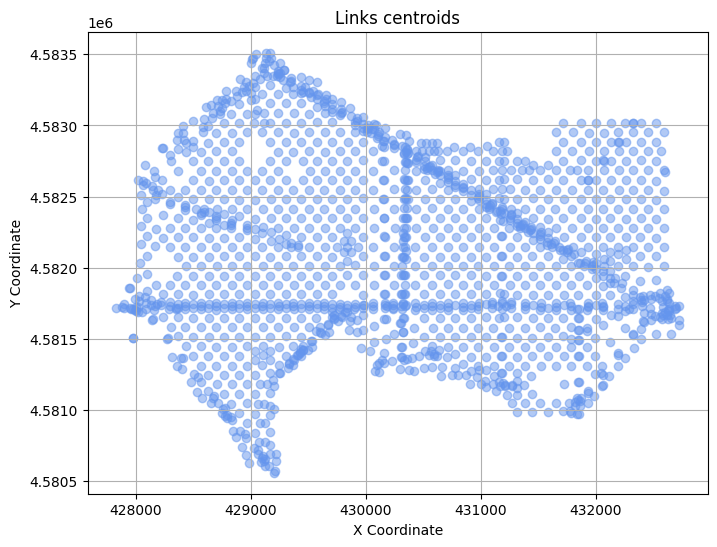

In [23]:
# Tracer x en abscisse et y en ordonnée
plt.figure(figsize=(8, 6))  # Taille du graphique
plt.scatter(df_pos["c_x"], df_pos["c_y"], color="cornflowerblue", alpha=0.5)  # Scatter plot

# Ajouter des titres et labels
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.title("Links centroids")
plt.grid(True)

# Afficher le graphique
plt.show()


In [20]:
df = df_pos[['id', 'c_x', 'c_y']].copy()

# Définition du nombre de lignes et colonnes de la grille
n_rows, n_cols = 30, 30

# Déterminer les bornes des points
xmin1, ymin1 = df[['c_x', 'c_y']].min()
xmax1, ymax1 = df[['c_x', 'c_y']].max()

# Ajuster les bordures
xmin = xmin1 - 0.05*(xmax1-xmin1)
xmax = xmax1 + 0.05*(xmax1-xmin1)

ymin = ymin1 - 0.05*(ymax1-ymin1)
ymax = ymax1 + 0.05*(ymax1-ymin1)

# Calculer la taille des cellules de la grille
cell_width = (xmax - xmin) / n_cols
cell_height = (ymax - ymin) / n_rows

# Fonction pour obtenir l'indice de grille d'un point
def assign_to_grid(x, y):
    col = int((x - xmin) / cell_width)
    row = int((ymax - y) / cell_height)  # Inversion pour que 0 soit en haut
    col = min(col, n_cols - 1)  # S'assurer que les indices restent dans la grille
    row = min(row, n_rows - 1)
    return (row, col)

# Appliquer l'assignation de grille à chaque point
df['grid_cell'] = df.apply(lambda row: assign_to_grid(row['c_x'], row['c_y']), axis=1)

# Afficher le DataFrame résultant dans la console
print(df)

         id            c_x           c_y grid_cell
0       512  429919.864530  4.583030e+06   (5, 13)
1       513  429910.282390  4.583025e+06   (5, 12)
2       514  429908.548351  4.583006e+06   (6, 12)
3       516  432567.505979  4.582818e+06   (7, 27)
4       593  432699.655713  4.581715e+06  (17, 28)
...     ...            ...           ...       ...
1565  69622  428351.221853  4.581708e+06   (18, 4)
1566  70330  430353.040038  4.581737e+06  (17, 15)
1567  72127  429984.156807  4.581739e+06  (17, 13)
1568  73054  430360.070670  4.582800e+06   (7, 15)
1569  73546  427897.525841  4.581714e+06   (17, 1)

[1570 rows x 4 columns]


In [21]:
def visualizeGrid(xmin, xmax, n_cols, n_rows):
    # Visualisation
    fig, ax = plt.subplots(figsize=(6,6))
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    # Dessiner la grille
    for i in range(1, n_cols):
        ax.axvline(xmin + i * cell_width, color='gray', linestyle='--')
    for i in range(1, n_rows):
        ax.axhline(ymin + i * cell_height, color='gray', linestyle='--')

    # Afficher les points avec leur ID et leur cellule
    for _, row in df.iterrows():
        ax.scatter(row['c_x'], row['c_y'], color='blue')
        #ax.text(row['c_x'], row['c_y'], f"{row['id']}", fontsize=8, verticalalignment='bottom')

    plt.show()

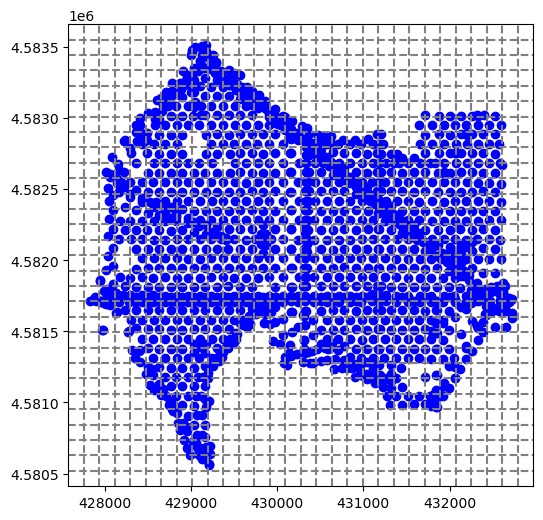

In [22]:
visualizeGrid(xmin, xmax, n_cols, n_rows)

In [23]:
# Définition de la cellule à analyser (exemple : ligne 2, colonne 3)
target_cell = (12, 6)

# Filtrer les IDs appartenant à cette cellule
ids_in_cell = df[df['grid_cell'] == target_cell]['id'].tolist()

# Afficher les résultats
print(f"IDs dans la cellule {target_cell} : {ids_in_cell}, Nombre total: {len(ids_in_cell)}")


IDs dans la cellule (12, 6) : [9388, 9389, 9590, 9840, 9841, 9849, 9850, 10183], Nombre total: 8


In [24]:
df_linkSpeed.loc['2005-05-10 07:48:00', 513]

11.404638919492243

In [33]:
df_linkSpeed.head()

section,512,513,514,516,593,594,595,596,597,598,...,64715,64751,64752,68076,69616,69622,70330,72127,73054,73546
time,,,,,,,,,,,,,,,,,,,,,
2005-05-10 07:48:00,0.000000,11.404639,11.069793,10.306622,0.000000,10.732761,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,8.633578,0.000000,11.051522
2005-05-10 07:51:00,11.546255,10.745354,11.502900,10.259055,11.557406,11.352791,0.0,11.393155,11.446191,10.130130,...,0.0,0.0,0.0,0.000000,0.0,7.831341,11.103996,10.547758,11.174799,10.955367
2005-05-10 07:54:00,11.360561,9.946858,10.903842,9.730855,10.714279,10.850517,0.0,10.862608,10.846595,9.294876,...,0.0,0.0,0.0,0.000000,0.0,7.810169,9.411075,11.458904,10.176731,10.699288
2005-05-10 07:57:00,10.377132,9.978746,11.079693,10.239193,11.465084,11.422663,0.0,11.485102,11.468658,10.193103,...,0.0,0.0,0.0,0.000000,0.0,6.566019,9.793065,8.694662,10.272738,10.948975
2005-05-10 08:00:00,10.099598,10.778375,10.390805,10.758182,10.697243,11.173762,0.0,10.641167,10.648340,9.481818,...,0.0,0.0,0.0,5.204891,0.0,5.134694,9.332022,8.636250,0.000000,11.485636


In [6]:
df_pos.head()

,id,from_x,from_y,to_x,to_y,length,out_ang,num_lanes,c_x,c_y,cluster,grid_x,grid_y,grid_nb
0,512,429868.903817,4.583001e+06,429970.825243,4.583058e+06,109.223967,2.682968,3,429919.864530,4.583030e+06,2,1954.0,20831.0,102
1,513,429850.190034,4.582992e+06,429970.374746,4.583058e+06,129.668226,-0.460007,3,429910.282390,4.583025e+06,2,1954.0,20831.0,102
2,514,429847.715438,4.582973e+06,429969.381264,4.583039e+06,133.572676,-0.472544,2,429908.548351,4.583006e+06,2,1954.0,20831.0,102
3,516,432543.672415,4.582815e+06,432591.339542,4.582821e+06,47.649609,3.138638,2,432567.505979,4.582818e+06,1,1966.0,20830.0,210
4,593,432651.332765,4.581710e+06,432747.978661,4.581720e+06,96.553540,0.010899,3,432699.655713,4.581715e+06,1,1966.0,20825.0,205


In [52]:
list_timestep = df_linkSpeed.index.astype(str).tolist()

In [ ]:
def createTensor(timestep, id, n_rows, n_cols, df, df_id):

    tensor = np.zeros((n_rows, n_cols))

    for i in range(n_rows):
        for j in range(n_cols):
            somme = 0
            target_cell = (i,j)
            ids_in_cell = df[df['grid_cell'] == target_cell]['id'].tolist()
            for idx in ids_in_cell:
                somme+= df_id.loc[timestep, idx]
            if id == 'ld_speed':
                if len(ids_in_cell) == 0:
                    tensor[i,j] = 0 
                else: 
                    tensor[i,j] = somme/len(ids_in_cell)
            else: 
                if len(ids_in_cell) == 0:
                    tensor[i,j] = 0 
                else: 
                    tensor[i,j] = somme
    return tensor

In [28]:
tensor = createTensor('2005-05-10 07:48:00', 'ld_speed', n_rows, n_cols, df, df_linkSpeed)

In [49]:
list_timestep

DatetimeIndex(['2005-05-10 07:48:00', '2005-05-10 07:51:00',
               '2005-05-10 07:54:00', '2005-05-10 07:57:00',
               '2005-05-10 08:00:00', '2005-05-10 08:03:00',
               '2005-05-10 08:06:00', '2005-05-10 08:09:00',
               '2005-05-10 08:12:00', '2005-05-10 08:15:00',
               '2005-05-10 08:18:00', '2005-05-10 08:21:00',
               '2005-05-10 08:24:00', '2005-05-10 08:27:00',
               '2005-05-10 08:30:00', '2005-05-10 08:33:00',
               '2005-05-10 08:36:00', '2005-05-10 08:39:00',
               '2005-05-10 08:42:00', '2005-05-10 08:45:00',
               '2005-05-10 08:48:00', '2005-05-10 08:51:00',
               '2005-05-10 08:54:00', '2005-05-10 08:57:00',
               '2005-05-10 09:00:00', '2005-05-10 09:03:00',
               '2005-05-10 09:06:00', '2005-05-10 09:09:00',
               '2005-05-10 09:12:00', '2005-05-10 09:15:00',
               '2005-05-10 09:18:00', '2005-05-10 09:21:00',
               '2005-05-

In [58]:
listTensor = []
for i in list_timestep:
    tensor = createTensor(i, 'ld_speed', n_rows, n_cols, df, df_linkSpeed)
    listTensor.append(tensor)

tensor3D = np.stack(listTensor, axis = 0)

In [69]:
df_linkSpeed.shape

(53, 1570)

In [68]:
tensor3D.shape

(53, 30, 30)

In [66]:
tensor3D[0,:10,:10]

array([[ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        , 11.0591007 ,  6.67347008, 11.43008742],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        , 11.08898832,  9.14111437,  8.29949649],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  8.00880928,  8.40756978,  9.36952411],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         5.12592411,  5.51619588, 10.49662008,  2.89239685, 12.66427878],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         5.5468509 ,  8.34582964,  0.        ,  9.96652605, 11.0012124 ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  8.3594158 ,
         6.76250296, 10.86661406, 11.34987529

In [ ]:

df_linkSpeed.shape

(53, 1570)

In [57]:
#dummyTensor = np.zeros((n_rows, n_cols))
for i in list_timestep:
    tensor = createTensor(i, 'ld_speed', n_rows, n_cols, df, df_linkSpeed)
    # stacked = np.stack((dummyTensor, tensor), axis = 0)
    # dummyTensor = stacked

In [67]:
tensor.shape

(30, 30)

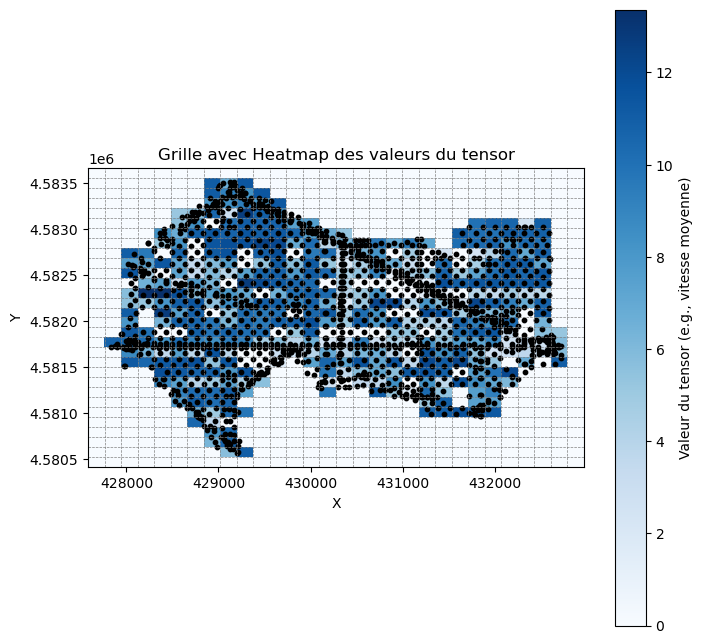

In [44]:
# Fonction pour visualiser la grille avec une heatmap
def visualize_grid_with_heatmap(xmin, xmax, ymin, ymax, n_cols, n_rows, tensor):
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Affichage de la heatmap
    im = ax.imshow(tensor, cmap='Blues', interpolation='nearest', origin='upper', extent=[xmin, xmax, ymin, ymax])

    # Ajouter la barre de couleur
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Valeur du tensor (e.g., vitesse moyenne)")

    # Dessiner la grille
    for i in range(1, n_cols):
        ax.axvline(xmin + i * cell_width, color='gray', linestyle='--', linewidth=0.5)
    for i in range(1, n_rows):
        ax.axhline(ymin + i * cell_height, color='gray', linestyle='--', linewidth=0.5)

    # Afficher les points
    for _, row in df.iterrows():
        ax.scatter(row['c_x'], row['c_y'], color='black', s=10)

    plt.title("Grille avec Heatmap des valeurs du tensor")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()

# Appel de la fonction pour afficher la heatmap
visualize_grid_with_heatmap(xmin, xmax, ymin, ymax, n_cols, n_rows, tensor)
